In [1]:
## Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.dummy import DummyRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    median_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
    make_scorer
)

import joblib

# 1. Business Understanding

## Goal

The goal of this project is to estimate a developer's annual salary in USD using structured information from the Stack Overflow Developer Survey.

This notebook represents **Model Iteration 2**.

Compared with the first basic iteration, this iteration:

1. Keeps a much broader range of suitable structured features.
2. Removes identifiers, salary leakage, preference-based fields and open-text fields.
3. Separates multi-select answers before encoding.
4. Applies one-hot encoding to categorical features.
5. Applies StandardScaler before PCA.
6. Uses PCA to reduce the expanded feature space while retaining 95% of its variance.
7. Compares raw-salary and log-salary model versions.

PCA is tested as an improvement rather than assumed to be the final solution. Its performance will be compared using the same regression metrics as the earlier iteration.

# 2. Data Understanding

## 2.1 Load Dataset

In [2]:
## Read survey data into pandas DataFrame
FILE_PATH = "results.csv"

df = pd.read_csv(
    FILE_PATH,
    low_memory=False
)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (49191, 172)


,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,104413.0,9.0
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code;GitHub Copilot;Google Gemini,NaN,When I don’t trust AI’s answers;When I want to...,"Understand how things actually work, problem s...",53061.0,8.0
3,4,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,4.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code,NaN,When I don’t trust AI’s answers;When I want to...,NaN,36197.0,6.0
4,5,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...","Caring for dependents (children, elderly, etc.)",21.0,"No, I am not new to coding and did not learn n...",NaN,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers,"critical thinking, the skill to define the tas...",60000.0,7.0


## 2.2 Summary Statistics

In [3]:
## Understand the type of variable for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49191 entries, 0 to 49190
Columns: 172 entries, ResponseId to JobSat
dtypes: float64(52), int64(1), object(119)
memory usage: 64.6+ MB


In [4]:
## Check for missing data
missing_summary = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Missing Percentage": (
        df.isna().mean() * 100
    ).round(2)
}).sort_values(
    "Missing Percentage",
    ascending=False
)

missing_summary.head(20)

,Missing Values,Missing Percentage
AIAgentObsWrite,48927,99.46
SOTagsWant Entry,48761,99.13
SOTagsHaveEntry,48733,99.07
AIModelsWantEntry,48716,99.03
AIAgentOrchWrite,48713,99.03
JobSatPoints_15_TEXT,48527,98.65
AIAgentKnowWrite,48425,98.44
AIModelsHaveEntry,48415,98.42
SO_Actions_15_TEXT,48368,98.33
AIAgentExtWrite,48332,98.25


In [5]:
## Describe the target distribution
target_column = "ConvertedCompYearly"

df[target_column] = pd.to_numeric(
    df[target_column],
    errors="coerce"
)

df[target_column].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

count    2.394700e+04
mean     1.017615e+05
std      4.617569e+05
min      1.000000e+00
25%      3.817100e+04
50%      7.532000e+04
75%      1.205960e+05
90%      1.840000e+05
95%      2.320290e+05
99%      4.408560e+05
max      5.000000e+07
Name: ConvertedCompYearly, dtype: float64

## 2.3 Data Visualisation

### 2.3.1 Salary Distribution

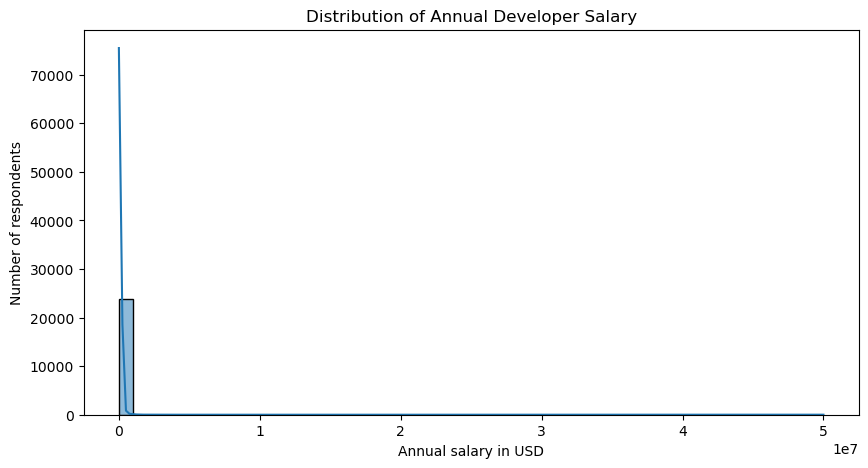

In [6]:
## Display the original salary distribution
plt.figure(figsize=(10, 5))

sns.histplot(
    df[target_column].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Annual Developer Salary")
plt.xlabel("Annual salary in USD")
plt.ylabel("Number of respondents")
plt.show()

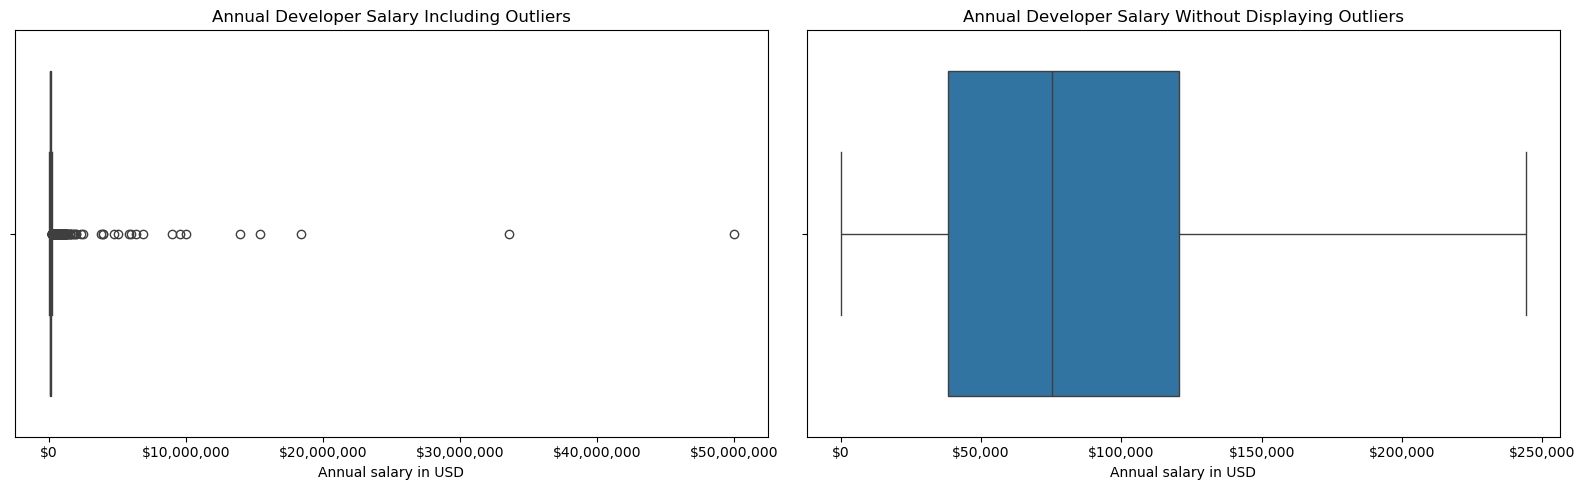

In [7]:
## Compare the complete distribution with the typical salary range
from matplotlib.ticker import StrMethodFormatter

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 5)
)

sns.boxplot(
    x=df[target_column],
    ax=axes[0]
)

axes[0].set_title(
    "Annual Developer Salary Including Outliers"
)
axes[0].set_xlabel(
    "Annual salary in USD"
)
axes[0].xaxis.set_major_formatter(
    StrMethodFormatter("${x:,.0f}")
)

sns.boxplot(
    x=df[target_column],
    showfliers=False,
    ax=axes[1]
)

axes[1].set_title(
    "Annual Developer Salary Without Displaying Outliers"
)
axes[1].set_xlabel(
    "Annual salary in USD"
)
axes[1].xaxis.set_major_formatter(
    StrMethodFormatter("${x:,.0f}")
)

plt.tight_layout()
plt.show()

# 3. Data Preparation

## 3.1 Define the Modelling Population

In [8]:
## Create a separate copy so that the original DataFrame remains unchanged
model_df = df.copy()

## Check the salary values before filtering
salary_checks = pd.Series({
    "Missing salary": model_df[target_column].isna().sum(),
    "Zero salary": (model_df[target_column] == 0).sum(),
    "Negative salary": (model_df[target_column] < 0).sum(),
    "Salary above USD 1 million": (
        model_df[target_column] > 1_000_000
    ).sum()
})

salary_checks

Missing salary                25244
Zero salary                       0
Negative salary                   0
Salary above USD 1 million       46
dtype: int64

In [9]:
## Keep employed respondents with a positive reported salary
##
## Zero and negative values are excluded because the application
## estimates positive annual compensation for paid employment.
##
## Large positive salaries are not automatically removed because
## they may still be valid. Their influence will later be reduced
## through a log-target experiment.

model_df = model_df[
    model_df["Employment"].eq("Employed")
    & model_df[target_column].notna()
    & (model_df[target_column] > 0)
].copy()

print(
    "Rows remaining for modelling:",
    len(model_df)
)

Rows remaining for modelling: 19500


## 3.2 Inspect Questionable Values

In [10]:
## Convert known numeric-like survey columns
numeric_like_columns = [
    "YearsCode",
    "WorkExp",
    "ToolCountWork",
    "ToolCountPersonal",
    "JobSat"
]

numeric_like_columns += [
    column
    for column in model_df.columns
    if column.startswith("JobSatPoints_")
]

for column in numeric_like_columns:
    if column in model_df.columns:
        model_df[column] = model_df[column].replace({
            "Less than 1 year": 0.5,
            "More than 50 years": 51
        })

        model_df[column] = pd.to_numeric(
            model_df[column],
            errors="coerce"
        )

In [11]:
## Flag unusual responses for investigation
## These records are not automatically deleted

model_df["QualityFlag"] = ""

if "YearsCode" in model_df.columns:
    model_df.loc[
        model_df["YearsCode"] > 70,
        "QualityFlag"
    ] += "Unusually high YearsCode; "

if "WorkExp" in model_df.columns:
    model_df.loc[
        model_df["WorkExp"] > 70,
        "QualityFlag"
    ] += "Unusually high WorkExp; "

model_df.loc[
    model_df[target_column] > 1_000_000,
    "QualityFlag"
] += "Salary above USD 1 million; "

quality_review = model_df[
    model_df["QualityFlag"] != ""
][
    [
        column
        for column in [
            "ResponseId",
            "YearsCode",
            "WorkExp",
            target_column,
            "QualityFlag"
        ]
        if column in model_df.columns
    ]
]

print(
    "Rows flagged for review:",
    len(quality_review)
)

quality_review.head(20)

Rows flagged for review: 39


,ResponseId,YearsCode,WorkExp,ConvertedCompYearly,QualityFlag
2009,2010,25.0,14.0,1006403.0,Salary above USD 1 million;
2668,2669,25.0,23.0,1300000.0,Salary above USD 1 million;
2725,2726,17.0,13.0,1250000.0,Salary above USD 1 million;
2812,2813,24.0,19.0,1200000.0,Salary above USD 1 million;
3265,3266,30.0,23.0,1500000.0,Salary above USD 1 million;
4583,4584,30.0,30.0,1160147.0,Salary above USD 1 million;
4842,4843,25.0,25.0,1100000.0,Salary above USD 1 million;
5327,5328,22.0,11.0,1950000.0,Salary above USD 1 million;
5410,5411,18.0,11.0,2346000.0,Salary above USD 1 million;
9310,9311,7.0,6.0,1500000.0,Salary above USD 1 million;


# 4. Model Iteration 3 – Meaningful Features and PCA Reconsideration

This iteration improves the previous expanded-feature experiment by deliberately
selecting features that are more closely related to salary.

The previous iteration included many survey behaviour and opinion variables.
PCA retained variation from those variables even when they were not clearly
useful for salary prediction.

Iteration 3 therefore:

1. Selects employment, experience and demographic features manually.
2. Excludes multi-select technology columns from one-hot encoding.
3. Converts `DevType` into one single `PrimaryDevType` feature.
4. Groups rare countries, industries and developer roles into `Other`.
5. Keeps the log-transformed target because it reduced the effect of extreme salaries.
6. Compares the same Gradient Boosting model with and without PCA.
7. Tunes only the better feature representation.


## 4.1 Select Meaningful Features

The variables `model_df` and `target_column` are reused from the earlier
data-cleaning section.


In [12]:

## so that earlier iteration variables remain unchanged.

model_df_iter3 = model_df.copy()


## DevType can contain multiple roles separated by semicolons.
## Instead of multi-hot encoding every role, keep the first role
## as the respondent's primary developer type.

if "DevType" in model_df_iter3.columns:
    model_df_iter3["PrimaryDevType"] = (
        model_df_iter3["DevType"]
        .fillna("Unknown")
        .astype(str)
        .str.split(";")
        .str[0]
        .str.strip()
    )


In [13]:
## Select exact features that are meaningful for salary prediction

numerical_features_iter3 = [
    "WorkExp",
    "YearsCode",
    "ToolCountWork",
    "ToolCountPersonal"
]

categorical_features_iter3 = [
    "Country",
    "Age",
    "EdLevel",
    "PrimaryDevType",
    "OrgSize",
    "ICorPM",
    "RemoteWork",
    "Industry",
    "PurchaseInfluence",
    "NewRole"
]


## Keep only columns that exist in the dataset

numerical_features_iter3 = [
    column
    for column in numerical_features_iter3
    if column in model_df_iter3.columns
]

categorical_features_iter3 = [
    column
    for column in categorical_features_iter3
    if column in model_df_iter3.columns
]

selected_features_iter3 = (
    numerical_features_iter3
    + categorical_features_iter3
)


## Show whether any intended features were unavailable

intended_features_iter3 = [
    "WorkExp",
    "YearsCode",
    "ToolCountWork",
    "ToolCountPersonal",
    "Country",
    "Age",
    "EdLevel",
    "PrimaryDevType",
    "OrgSize",
    "ICorPM",
    "RemoteWork",
    "Industry",
    "PurchaseInfluence",
    "NewRole"
]

missing_features_iter3 = [
    column
    for column in intended_features_iter3
    if column not in model_df_iter3.columns
]


print(
    "Selected numerical features:",
    numerical_features_iter3
)

print(
    "\nSelected categorical features:",
    categorical_features_iter3
)

print(
    "\nMissing intended features:",
    missing_features_iter3
)

print(
    "\nTotal selected features:",
    len(selected_features_iter3)
)


Selected numerical features: ['WorkExp', 'YearsCode', 'ToolCountWork', 'ToolCountPersonal']

Selected categorical features: ['Country', 'Age', 'EdLevel', 'PrimaryDevType', 'OrgSize', 'ICorPM', 'RemoteWork', 'Industry', 'PurchaseInfluence', 'NewRole']

Missing intended features: []

Total selected features: 14


In [14]:
## Create the feature and target variables

x_iter3 = model_df_iter3[
    selected_features_iter3
].copy()

y_iter3 = model_df_iter3[
    target_column
].copy()


## Use the same split settings as Iteration 2
## so that the comparison remains fair.

x_train_iter3, x_test_iter3, y_train_iter3, y_test_iter3 = (
    train_test_split(
        x_iter3,
        y_iter3,
        test_size=0.2,
        random_state=676767
    )
)


print(
    "Training feature shape:",
    x_train_iter3.shape
)

print(
    "Testing feature shape:",
    x_test_iter3.shape
)


Training feature shape: (15600, 14)
Testing feature shape: (3900, 14)


## 4.2 Prepare Numerical Features


In [15]:
## Fill missing numerical values using medians
## learned from the training data only.

training_medians_iter3 = {}

x_train_numeric_iter3 = pd.DataFrame(
    index=x_train_iter3.index
)

x_test_numeric_iter3 = pd.DataFrame(
    index=x_test_iter3.index
)


for column in numerical_features_iter3:

    train_numeric = pd.to_numeric(
        x_train_iter3[column],
        errors="coerce"
    )

    test_numeric = pd.to_numeric(
        x_test_iter3[column],
        errors="coerce"
    )

    training_medians_iter3[column] = (
        train_numeric.median()
    )

    x_train_numeric_iter3[column] = (
        train_numeric.fillna(
            training_medians_iter3[column]
        )
    )

    x_test_numeric_iter3[column] = (
        test_numeric.fillna(
            training_medians_iter3[column]
        )
    )


print(
    "Numerical training shape:",
    x_train_numeric_iter3.shape
)


Numerical training shape: (15600, 4)


## 4.3 Prepare and Encode Categorical Features


In [16]:
## Fill missing categorical values

for column in categorical_features_iter3:

    x_train_iter3[column] = (
        x_train_iter3[column]
        .fillna("Unknown")
        .astype(str)
    )

    x_test_iter3[column] = (
        x_test_iter3[column]
        .fillna("Unknown")
        .astype(str)
    )


## Group rare categories using only training-data frequencies.
## This prevents Country, Industry and PrimaryDevType
## from producing too many one-hot encoded columns.

category_limits_iter3 = {
    "Country": 20,
    "Industry": 15,
    "PrimaryDevType": 15
}

top_categories_iter3 = {}


for column, limit in category_limits_iter3.items():

    if column not in categorical_features_iter3:
        continue

    top_categories_iter3[column] = (
        x_train_iter3[column]
        .value_counts()
        .head(limit)
        .index
        .tolist()
    )

    x_train_iter3[column] = (
        x_train_iter3[column]
        .where(
            x_train_iter3[column].isin(
                top_categories_iter3[column]
            ),
            "Other"
        )
    )

    x_test_iter3[column] = (
        x_test_iter3[column]
        .where(
            x_test_iter3[column].isin(
                top_categories_iter3[column]
            ),
            "Other"
        )
    )


In [17]:
## One-hot encode only the selected single-choice features.
##
## Multi-select technology columns are not included in this iteration.

x_train_categorical_iter3 = pd.get_dummies(
    x_train_iter3[
        categorical_features_iter3
    ],
    drop_first=True,
    dtype=int
)

x_test_categorical_iter3 = pd.get_dummies(
    x_test_iter3[
        categorical_features_iter3
    ],
    drop_first=True,
    dtype=int
)


## Ensure the testing data uses the same columns
## and column order as the training data.

x_test_categorical_iter3 = (
    x_test_categorical_iter3.reindex(
        columns=x_train_categorical_iter3.columns,
        fill_value=0
    )
)


print(
    "Original categorical features:",
    len(categorical_features_iter3)
)

print(
    "One-hot encoded features created:",
    x_train_categorical_iter3.shape[1]
)


Original categorical features: 10
One-hot encoded features created: 90


## 4.4 Combine the Selected Features


In [18]:
## Combine numerical and one-hot encoded features

x_train_encoded_iter3 = pd.concat(
    [
        x_train_numeric_iter3,
        x_train_categorical_iter3
    ],
    axis=1
)

x_test_encoded_iter3 = pd.concat(
    [
        x_test_numeric_iter3,
        x_test_categorical_iter3
    ],
    axis=1
)


## Ensure the same feature structure

x_test_encoded_iter3 = (
    x_test_encoded_iter3.reindex(
        columns=x_train_encoded_iter3.columns,
        fill_value=0
    )
)


## Convert all model inputs into floats

x_train_encoded_iter3 = (
    x_train_encoded_iter3.astype(float)
)

x_test_encoded_iter3 = (
    x_test_encoded_iter3.astype(float)
)


## Remove encoded features with no variation

zero_variance_iter3 = (
    x_train_encoded_iter3
    .nunique(dropna=False)
)

zero_variance_iter3 = (
    zero_variance_iter3[
        zero_variance_iter3 <= 1
    ]
    .index
    .tolist()
)

x_train_encoded_iter3 = (
    x_train_encoded_iter3.drop(
        columns=zero_variance_iter3
    )
)

x_test_encoded_iter3 = (
    x_test_encoded_iter3.drop(
        columns=zero_variance_iter3
    )
)


print(
    "Original selected features:",
    len(selected_features_iter3)
)

print(
    "Final encoded features:",
    x_train_encoded_iter3.shape[1]
)

print(
    "Encoded training shape:",
    x_train_encoded_iter3.shape
)

print(
    "Encoded testing shape:",
    x_test_encoded_iter3.shape
)


Original selected features: 14
Final encoded features: 94
Encoded training shape: (15600, 94)
Encoded testing shape: (3900, 94)


## 4.5 Confirm That Important Features Were Included


In [21]:
## Create the Iteration 3 feature DataFrame

X_iter3 = model_df_iter3[
    selected_features_iter3
].copy()

y_iter3 = model_df_iter3[
    target_column
].copy()


## Fill missing numerical values

for column in numerical_features_iter3:

    X_iter3[column] = (
        X_iter3[column]
        .fillna(
            X_iter3[column].median()
        )
    )


## Fill missing categorical values

for column in categorical_features_iter3:

    X_iter3[column] = (
        X_iter3[column]
        .fillna("Unknown")
    )


## One-hot encode the categorical columns

X_iter3 = pd.get_dummies(
    X_iter3,
    drop_first=True
)


print(
    "Original selected features:",
    len(selected_features_iter3)
)

print(
    "Features after one-hot encoding:",
    X_iter3.shape[1]
)

print(
    "Final feature shape:",
    X_iter3.shape
)

Original selected features: 14
Features after one-hot encoding: 243
Final feature shape: (19500, 243)


## 4.6 Apply PCA for a Fair Comparison


In [22]:
## Standardise the selected encoded features before PCA

scaler_iter3 = StandardScaler()

x_train_scaled_iter3 = (
    scaler_iter3.fit_transform(
        x_train_encoded_iter3
    )
)

x_test_scaled_iter3 = (
    scaler_iter3.transform(
        x_test_encoded_iter3
    )
)


## Retain 95% of the input-feature variance

pca_iter3 = PCA(
    n_components=0.95,
    svd_solver="full"
)

x_train_pca_iter3 = (
    pca_iter3.fit_transform(
        x_train_scaled_iter3
    )
)

x_test_pca_iter3 = (
    pca_iter3.transform(
        x_test_scaled_iter3
    )
)


print(
    "Features before PCA:",
    x_train_encoded_iter3.shape[1]
)

print(
    "Components after PCA:",
    x_train_pca_iter3.shape[1]
)

print(
    "Variance retained:",
    round(
        pca_iter3
        .explained_variance_ratio_
        .sum(),
        4
    )
)


Features before PCA: 94
Components after PCA: 79
Variance retained: 0.9564


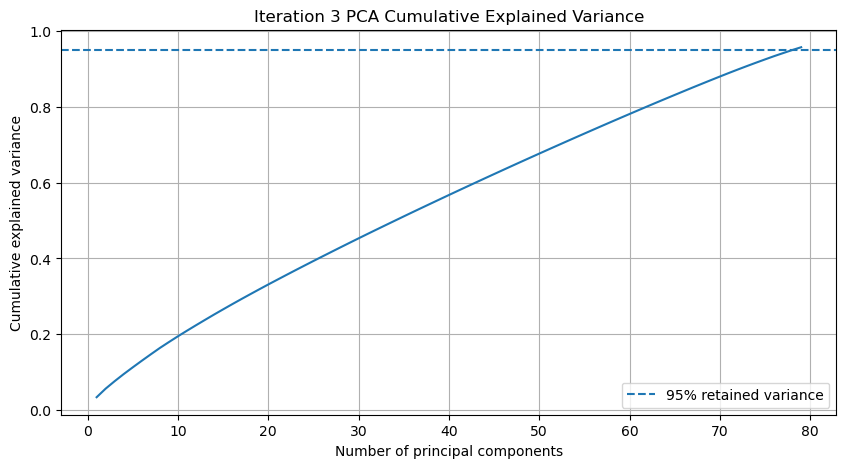

In [23]:
## Display cumulative explained variance

cumulative_variance_iter3 = np.cumsum(
    pca_iter3.explained_variance_ratio_
)

plt.figure(figsize=(10, 5))

plt.plot(
    range(
        1,
        len(cumulative_variance_iter3) + 1
    ),
    cumulative_variance_iter3
)

plt.axhline(
    y=0.95,
    linestyle="--",
    label="95% retained variance"
)

plt.title(
    "Iteration 3 PCA Cumulative Explained Variance"
)

plt.xlabel(
    "Number of principal components"
)

plt.ylabel(
    "Cumulative explained variance"
)

plt.legend()
plt.grid()
plt.show()


# 5. Iteration 3 Modelling

Both Gradient Boosting models below use:

- The same rows.
- The same selected original features.
- The same train-test split.
- The same log-transformed salary target.
- The same model settings.

The only difference is whether PCA is applied.


In [24]:
## Evaluation function for Iteration 3

iteration3_results = []


def evaluate_iteration3(
    model_name,
    actual_values,
    predicted_values
):

    predicted_values = np.maximum(
        predicted_values,
        0
    )

    result = {
        "Model": model_name,

        "MAE": mean_absolute_error(
            actual_values,
            predicted_values
        ),

        "Median Absolute Error": (
            median_absolute_error(
                actual_values,
                predicted_values
            )
        ),

        "MSE": mean_squared_error(
            actual_values,
            predicted_values
        ),

        "RMSE": root_mean_squared_error(
            actual_values,
            predicted_values
        ),

        "R2": r2_score(
            actual_values,
            predicted_values
        )
    }

    iteration3_results.append(result)

    return result


## 5.1 Median Baseline


In [25]:
## Train the same median baseline used previously

baseline_iter3 = DummyRegressor(
    strategy="median"
)

baseline_iter3.fit(
    x_train_encoded_iter3,
    y_train_iter3
)

y_pred_baseline_iter3 = (
    baseline_iter3.predict(
        x_test_encoded_iter3
    )
)

evaluate_iteration3(
    "Iteration 3 Median Baseline",
    y_test_iter3,
    y_pred_baseline_iter3
)


{'Model': 'Iteration 3 Median Baseline',
 'MAE': 58726.58974358974,
 'Median Absolute Error': 40826.0,
 'MSE': 19894522047.764614,
 'RMSE': 141047.94237338103,
 'R2': -0.018247690798921967}

## 5.2 Keep the Log-Transformed Target


In [26]:
## Log-transform the positive training salaries.
##
## This reduces the influence of extremely large salary values
## during model training.

y_train_log_iter3 = np.log1p(
    y_train_iter3
)


## 5.3 Gradient Boosting Without PCA


In [27]:
## Train Gradient Boosting using the selected encoded features directly

gradient_no_pca_iter3 = GradientBoostingRegressor(
    loss="huber",
    random_state=67
)

gradient_no_pca_iter3.fit(
    x_train_encoded_iter3,
    y_train_log_iter3
)

y_pred_no_pca_iter3 = np.expm1(
    gradient_no_pca_iter3.predict(
        x_test_encoded_iter3
    )
)

evaluate_iteration3(
    "Iteration 3 Gradient Boosting + Log Target - No PCA",
    y_test_iter3,
    y_pred_no_pca_iter3
)


{'Model': 'Iteration 3 Gradient Boosting + Log Target - No PCA',
 'MAE': 36926.86440888108,
 'Median Absolute Error': 19240.403619728146,
 'MSE': 16521440364.580976,
 'RMSE': 128535.75519901447,
 'R2': 0.1543944378499441}

## 5.4 Gradient Boosting With PCA


In [28]:
## Train the same Gradient Boosting model using PCA features

gradient_pca_iter3 = GradientBoostingRegressor(
    loss="huber",
    random_state=67
)

gradient_pca_iter3.fit(
    x_train_pca_iter3,
    y_train_log_iter3
)

y_pred_pca_iter3 = np.expm1(
    gradient_pca_iter3.predict(
        x_test_pca_iter3
    )
)

evaluate_iteration3(
    "Iteration 3 Gradient Boosting + Log Target - PCA",
    y_test_iter3,
    y_pred_pca_iter3
)


{'Model': 'Iteration 3 Gradient Boosting + Log Target - PCA',
 'MAE': 39930.07319491133,
 'Median Absolute Error': 21146.506665909415,
 'MSE': 16905971533.645922,
 'RMSE': 130022.96540859973,
 'R2': 0.13471324249372862}

## 5.5 Compare PCA and No-PCA Versions


In [29]:
## Compare the baseline, no-PCA and PCA versions

iteration3_comparison = pd.DataFrame(
    iteration3_results
)

baseline_mae_iter3 = iteration3_comparison.loc[
    iteration3_comparison["Model"].eq(
        "Iteration 3 Median Baseline"
    ),
    "MAE"
].iloc[0]

iteration3_comparison[
    "MAE Improvement vs Baseline (%)"
] = (
    (
        baseline_mae_iter3
        - iteration3_comparison["MAE"]
    )
    / baseline_mae_iter3
    * 100
)

iteration3_comparison = (
    iteration3_comparison
    .sort_values("MAE")
    .reset_index(drop=True)
)

iteration3_comparison


,Model,MAE,Median Absolute Error,MSE,RMSE,R2,MAE Improvement vs Baseline (%)
0,Iteration 3 Gradient Boosting + Log Target - N...,36926.864409,19240.403620,1.652144e+10,128535.755199,0.154394,37.120707
1,Iteration 3 Gradient Boosting + Log Target - PCA,39930.073195,21146.506666,1.690597e+10,130022.965409,0.134713,32.006825
2,Iteration 3 Median Baseline,58726.589744,40826.000000,1.989452e+10,141047.942373,-0.018248,0.000000


In [30]:
## Select the better feature representation using test MAE

no_pca_mae_iter3 = iteration3_comparison.loc[
    iteration3_comparison["Model"].eq(
        "Iteration 3 Gradient Boosting + Log Target - No PCA"
    ),
    "MAE"
].iloc[0]

pca_mae_iter3 = iteration3_comparison.loc[
    iteration3_comparison["Model"].eq(
        "Iteration 3 Gradient Boosting + Log Target - PCA"
    ),
    "MAE"
].iloc[0]


if pca_mae_iter3 < no_pca_mae_iter3:

    selected_representation_iter3 = "PCA"

    x_train_selected_iter3 = (
        x_train_pca_iter3
    )

    x_test_selected_iter3 = (
        x_test_pca_iter3
    )

else:

    selected_representation_iter3 = "No PCA"

    x_train_selected_iter3 = (
        x_train_encoded_iter3
    )

    x_test_selected_iter3 = (
        x_test_encoded_iter3
    )


print(
    "Selected representation:",
    selected_representation_iter3
)

print(
    "No-PCA MAE:",
    round(no_pca_mae_iter3, 2)
)

print(
    "PCA MAE:",
    round(pca_mae_iter3, 2)
)


Selected representation: No PCA
No-PCA MAE: 36926.86
PCA MAE: 39930.07


# 6. Hyperparameter Tuning

Only the better representation from the fair PCA versus no-PCA comparison
is tuned.


In [31]:
## Custom scorer that evaluates predictions in the original USD scale

def salary_mae_from_log_iter3(
    actual_log_salary,
    predicted_log_salary
):

    actual_salary = np.expm1(
        actual_log_salary
    )

    predicted_salary = np.expm1(
        predicted_log_salary
    )

    return mean_absolute_error(
        actual_salary,
        predicted_salary
    )


salary_mae_scorer_iter3 = make_scorer(
    salary_mae_from_log_iter3,
    greater_is_better=False
)


## Each hyperparameter contains no more than three choices

parameter_options_iter3 = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.03, 0.05, 0.10],
    "max_depth": [2, 3, 4],
    "min_samples_split": [2, 5, 10]
}


gradient_for_tuning_iter3 = (
    GradientBoostingRegressor(
        loss="huber",
        random_state=67
    )
)


random_search_iter3 = RandomizedSearchCV(
    estimator=gradient_for_tuning_iter3,
    param_distributions=parameter_options_iter3,
    n_iter=10,
    scoring=salary_mae_scorer_iter3,
    cv=3,
    random_state=67,
    n_jobs=-1
)


random_search_iter3.fit(
    x_train_selected_iter3,
    y_train_log_iter3
)


print(
    "Representation tuned:",
    selected_representation_iter3
)

print(
    "Best hyperparameters:"
)

print(
    random_search_iter3.best_params_
)


Representation tuned: No PCA
Best hyperparameters:
{'n_estimators': 300, 'min_samples_split': 2, 'max_depth': 3, 'learning_rate': 0.05}


In [32]:
## Display the Iteration 3 tuning logs

tuning_results_iter3 = pd.DataFrame(
    random_search_iter3.cv_results_
)[
    [
        "params",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].copy()

tuning_results_iter3 = (
    tuning_results_iter3
    .sort_values("rank_test_score")
)

tuning_results_iter3.head(10)


,params,mean_test_score,std_test_score,rank_test_score
8,"{'n_estimators': 300, 'min_samples_split': 2, ...",-42073.396802,6055.978854,1
1,"{'n_estimators': 300, 'min_samples_split': 2, ...",-42142.692914,5930.215516,2
3,"{'n_estimators': 100, 'min_samples_split': 5, ...",-42655.266911,6141.603979,3
6,"{'n_estimators': 300, 'min_samples_split': 2, ...",-42854.696988,6069.658643,4
7,"{'n_estimators': 300, 'min_samples_split': 2, ...",-43024.790258,6094.135982,5
5,"{'n_estimators': 200, 'min_samples_split': 2, ...",-43641.135049,6145.269853,6
9,"{'n_estimators': 100, 'min_samples_split': 5, ...",-43736.553262,6129.265892,7
2,"{'n_estimators': 100, 'min_samples_split': 5, ...",-44361.385296,6093.438812,8
4,"{'n_estimators': 200, 'min_samples_split': 5, ...",-44893.391367,6225.443342,9
0,"{'n_estimators': 100, 'min_samples_split': 2, ...",-46987.910874,6310.504064,10


## 6.1 Evaluate the Tuned Iteration 3 Model


In [33]:
## Evaluate the tuned model in normal USD

best_model_iter3 = (
    random_search_iter3.best_estimator_
)

y_pred_tuned_iter3 = np.expm1(
    best_model_iter3.predict(
        x_test_selected_iter3
    )
)

y_pred_tuned_iter3 = np.maximum(
    y_pred_tuned_iter3,
    0
)


tuned_result_iter3 = {
    "Model": (
        "Iteration 3 Tuned Gradient Boosting + "
        f"Log Target - {selected_representation_iter3}"
    ),

    "MAE": mean_absolute_error(
        y_test_iter3,
        y_pred_tuned_iter3
    ),

    "Median Absolute Error": (
        median_absolute_error(
            y_test_iter3,
            y_pred_tuned_iter3
        )
    ),

    "MSE": mean_squared_error(
        y_test_iter3,
        y_pred_tuned_iter3
    ),

    "RMSE": root_mean_squared_error(
        y_test_iter3,
        y_pred_tuned_iter3
    ),

    "R2": r2_score(
        y_test_iter3,
        y_pred_tuned_iter3
    )
}


final_results_iter3 = pd.concat(
    [
        iteration3_comparison.drop(
            columns=[
                "MAE Improvement vs Baseline (%)"
            ],
            errors="ignore"
        ),

        pd.DataFrame(
            [tuned_result_iter3]
        )
    ],
    ignore_index=True
)


final_results_iter3[
    "MAE Improvement vs Baseline (%)"
] = (
    (
        baseline_mae_iter3
        - final_results_iter3["MAE"]
    )
    / baseline_mae_iter3
    * 100
)


final_results_iter3 = (
    final_results_iter3
    .sort_values("MAE")
    .reset_index(drop=True)
)


final_results_iter3


,Model,MAE,Median Absolute Error,MSE,RMSE,R2,MAE Improvement vs Baseline (%)
0,Iteration 3 Tuned Gradient Boosting + Log Targ...,36320.039911,18643.121138,1.635334e+10,127880.163246,0.162998,38.154012
1,Iteration 3 Gradient Boosting + Log Target - N...,36926.864409,19240.403620,1.652144e+10,128535.755199,0.154394,37.120707
2,Iteration 3 Gradient Boosting + Log Target - PCA,39930.073195,21146.506666,1.690597e+10,130022.965409,0.134713,32.006825
3,Iteration 3 Median Baseline,58726.589744,40826.000000,1.989452e+10,141047.942373,-0.018248,0.000000


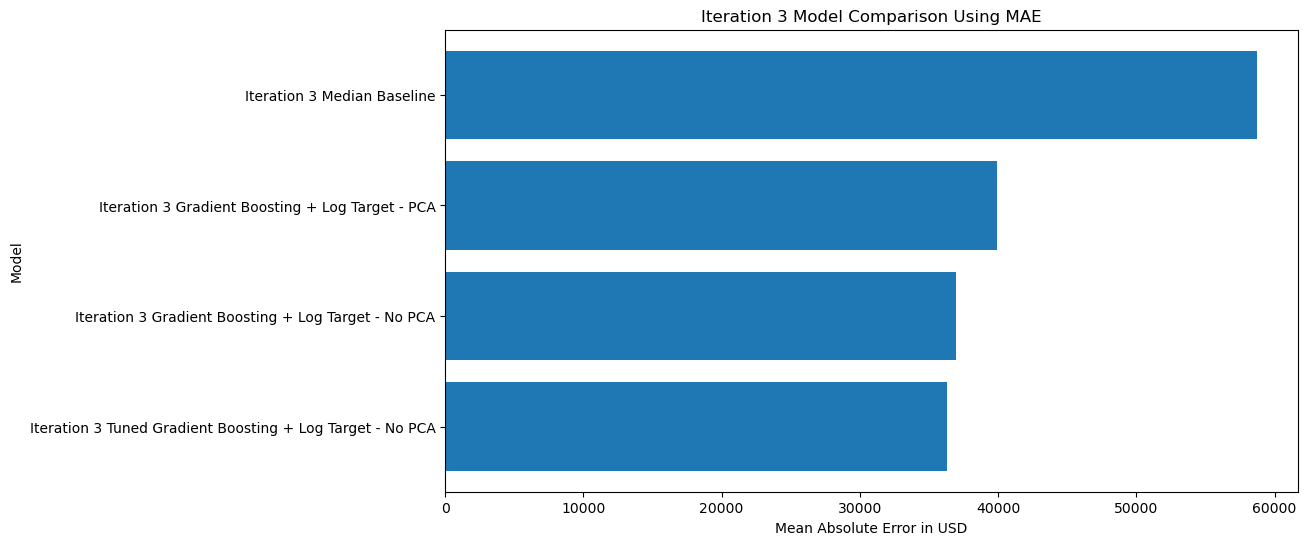

In [34]:
## Visualise the final Iteration 3 comparison

plt.figure(figsize=(11, 6))

plot_results_iter3 = (
    final_results_iter3
    .sort_values(
        "MAE",
        ascending=True
    )
)

plt.barh(
    plot_results_iter3["Model"],
    plot_results_iter3["MAE"]
)

plt.title(
    "Iteration 3 Model Comparison Using MAE"
)

plt.xlabel(
    "Mean Absolute Error in USD"
)

plt.ylabel(
    "Model"
)

plt.show()


## 6.2 Feature Importance for the Interpretable No-PCA Version


In [35]:
## Display feature importance from the no-PCA Gradient Boosting model.
##
## This remains useful even when PCA wins because it shows
## which readable encoded features influenced the model directly.

feature_importance_iter3 = pd.DataFrame({
    "Feature": x_train_encoded_iter3.columns,
    "Importance": (
        gradient_no_pca_iter3
        .feature_importances_
    )
}).sort_values(
    "Importance",
    ascending=False
)


feature_importance_iter3.head(15)


,Feature,Importance
23,Country_United States of America,0.328190
1,YearsCode,0.195054
0,WorkExp,0.131341
15,Country_Other,0.083728
11,Country_India,0.068710
21,Country_Ukraine,0.029560
5,Country_Brazil,0.029201
65,RemoteWork_In-person,0.021873
20,Country_Switzerland,0.016122
53,"OrgSize_10,000 or more employees",0.013131


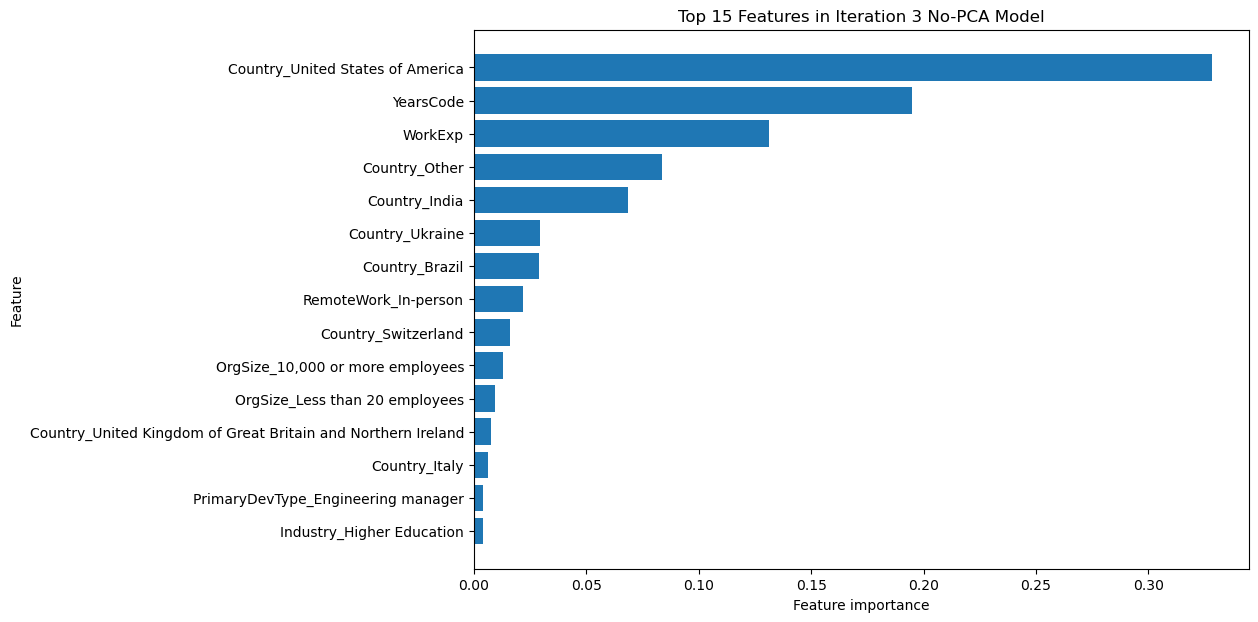

In [36]:
## Plot the 15 most important readable features

top_features_iter3 = (
    feature_importance_iter3.head(15)
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features_iter3["Feature"][::-1],
    top_features_iter3["Importance"][::-1]
)

plt.title(
    "Top 15 Features in Iteration 3 No-PCA Model"
)

plt.xlabel(
    "Feature importance"
)

plt.ylabel(
    "Feature"
)

plt.show()


## 6.3 Save the Iteration 3 Model


In [37]:
## Save the final model and preprocessing information
## required by the Streamlit application.

model_package_iter3 = {
    "model": best_model_iter3,

    "target_transform": "log1p",

    "selected_representation": (
        selected_representation_iter3
    ),

    "selected_features": (
        selected_features_iter3
    ),

    "numerical_features": (
        numerical_features_iter3
    ),

    "categorical_features": (
        categorical_features_iter3
    ),

    "training_medians": (
        training_medians_iter3
    ),

    "category_limits": (
        category_limits_iter3
    ),

    "top_categories": (
        top_categories_iter3
    ),

    "categorical_encoded_columns": (
        x_train_categorical_iter3
        .columns
        .tolist()
    ),

    "final_encoded_columns": (
        x_train_encoded_iter3
        .columns
        .tolist()
    ),

    "primary_dev_type_rule": (
        "Use the first semicolon-separated DevType value"
    ),

    "scaler": (
        scaler_iter3
        if selected_representation_iter3 == "PCA"
        else None
    ),

    "pca": (
        pca_iter3
        if selected_representation_iter3 == "PCA"
        else None
    )
}


joblib.dump(
    model_package_iter3,
    "salary_iteration3_model.pkl"
)


print(
    "Saved salary_iteration3_model.pkl"
)


Saved salary_iteration3_model.pkl


# 7. Iteration 3 Improvements

Iteration 3 introduced the following improvements:

1. **Meaningful manual feature selection**  
   Only employment, experience and demographic variables that can reasonably
   influence salary were retained.

2. **No multi-select one-hot encoding**  
   Programming language, database, platform and framework lists were excluded
   because multi-hot encoding created an excessively large and unstable feature
   space.

3. **Primary developer role feature engineering**  
   The first `DevType` response was converted into `PrimaryDevType`, allowing
   developer role information to remain in the model without multi-hot encoding.

4. **Rare-category grouping**  
   Less common countries, industries and developer roles were grouped as
   `Other`, reducing sparse one-hot encoded columns.

5. **Important-feature verification**  
   A table confirms that every selected feature created at least one model
   input before PCA.

6. **Log-transformed salary target retained**  
   `log1p` reduces the influence of extremely large salary values during
   training, while predictions are converted back to USD using `expm1`.

7. **Fair PCA reconsideration**  
   PCA and no-PCA models use the same features, rows, split, target
   transformation and Gradient Boosting settings.

8. **Evidence-based representation selection**  
   Only the better PCA or no-PCA representation is passed into
   hyperparameter tuning.

9. **Separate Iteration 3 variables**  
   Variables use the `_iter3` suffix so that Iteration 2 outputs are not
   overwritten.
